# Predicting Habitat Preference for Freshwater Fish

## Research Question
Can machine learning predict whether a freshwater fish species prefers flowing water or still water habitats based on its body size, feeding ecology, life history traits, and environmental characteristics?

## Background and Context

Freshwater fish species live in many different environments, including rivers, streams, lakes, and other freshwater habitats. Differences in body size, feeding behavior, life history traits, and environmental conditions may help explain why some species are more commonly associated with flowing water while others prefer still water.

Previous research supports using biological and ecological traits to study freshwater fish habitat patterns. Frimpong and Angermeier (2009) developed the FishTraits database to bring together information about feeding ecology, body size, life history, habitat preferences, and environmental characteristics for freshwater fish species in the United States.

Research by Goldstein and Meador (2004) found that fish traits such as feeding ecology, reproductive strategies, and habitat preferences can vary across different stream and river environments. Their later research also showed that fish species traits can provide useful information when examining differences in habitat conditions (Goldstein & Meador, 2005).

These studies support using fish characteristics as predictors in this project. Instead of assuming that one characteristic determines habitat preference, I use machine learning to examine how multiple biological and environmental characteristics work together when predicting whether a species prefers flowing or still water.

## 1. Data Collection

The goal of this section is to collect freshwater fish characteristics that may help predict habitat preference. Potential variables include body size, feeding ecology, life history traits, temperature tolerance, and other species specific characteristics.

### Potential Data Sources

This project uses the FishTraits database, which contains ecological and life history information for freshwater fish species in the United States.

The dataset includes information about species identification, feeding ecology, body size, reproductive and life history traits, habitat preferences, temperature related environmental characteristics, geographic distribution, and conservation status.

In [3]:
import pandas as pd

fish = pd.read_excel("FishTraits_14.3.xls")

fish.head()

,SID,ALTSID,NOTES,FID,GENUS,SPECIES,GID,ITISTSN,COMMONNAME,OTHERNAMES,...,LATRANGE,LONRANGE,LISTED,REASON,LIST1,LIST2,LIST3,LIST4,LIST5,EXTINCT
0,Apomotis,Apomotis,29,Centrarc,Acantharchus,pomotis,Acanthar,168095,mud sunfish,.,...,1569,700,0,0,0,0,0,0,0,O
1,Abreviro,Abreviro,7,Acipense,Acipenser,brevirostrum,Acipense,161069,shortnose sturgeon,.,...,2250,1139,1,1,1,1,0,0,0,O
2,Afulvesc,Afulvesc,16,Acipense,Acipenser,fulvescens,Acipense,161071,lake sturgeon,.,...,3095,3455,1,3,1,1,0,0,0,O
3,Amediros,Amediros,20,Acipense,Acipenser,medirostris,Acipense,161067,green sturgeon,.,...,3430,1721,1,3,1,1,0,0,0,O
4,Aoxyrinc,Aoxyrhyn,26,Acipense,Acipenser,oxyrinchus,Acipense,553269,Atlantic sturgeon,Gulf sturgeon,...,3591,2691,1,4,1,1,0,0,0,O


In [4]:
fish["COMMONNAME"].tolist()

['mud sunfish',
 'shortnose sturgeon',
 'lake sturgeon',
 'green sturgeon',
 'Atlantic sturgeon',
 'white sturgeon',
 'chiselmouth',
 'longfin dace',
 'blueback herring',
 'Alabama shad',
 'skipjack herring',
 'hickory shad',
 'alewife',
 'American Shad',
 'shadow bass',
 'Roanoke bass',
 'Ozark bass',
 'rock bass',
 'Ozark cavefish',
 'northern cavefish',
 'snail bullhead',
 'white catfish',
 'black bullhead',
 'yellow bullhead',
 'brown bullhead',
 'flat bullhead',
 'spotted bullhead',
 'bowfin',
 'naked sand darter',
 'Florida sand darter',
 'western sand darter',
 'southern sand darter',
 'eastern sand darter',
 'scaly sand darter',
 'fourspine stickleback',
 'pirate perch',
 'Sacramento perch',
 'oscar',
 'Mexican tetra',
 'alligator Gar',
 'pike killifish',
 'Siamese fighting fish',
 'zebra danio',
 'cascarudo',
 'central stoneroller',
 'largescale stoneroller',
 'Mexican stoneroller',
 'bluefin stoneroller',
 'goldfish',
 'river carpsucker',
 'quillback',
 'highfin carpsucker',


## 2. Data Exploration

Before preparing the data for machine learning I explored the dataset to understand its size, variables, and overall structure.

In [5]:
fish.shape

(809, 110)

In [6]:
fish[["COMMONNAME", "PREFLOT", "PREFLEN", "LACUSTRINE"]].head(10)

,COMMONNAME,PREFLOT,PREFLEN,LACUSTRINE
0,mud sunfish,0,1,1
1,shortnose sturgeon,1,0,0
2,lake sturgeon,0,1,1
3,green sturgeon,0,0,1
4,Atlantic sturgeon,1,0,0
5,white sturgeon,1,0,1
6,chiselmouth,1,0,1
7,longfin dace,1,0,0
8,blueback herring,1,0,1
9,Alabama shad,1,0,1


In [7]:
fish[["PREFLOT", "PREFLEN", "LACUSTRINE"]].value_counts()

PREFLOT  PREFLEN  LACUSTRINE
 1        0        0            509
 0        1        1             99
 1        0        1             80
 0        0        1             60
-555     -555     -555           29
                   1             19
 0        1       -555            7
                   0              2
-555     -555      0              2
 1        1        1              1
-555      1       -555            1
Name: count, dtype: int64

In [8]:
fish[["PREFLOT", "PREFLEN", "LACUSTRINE"]].apply(lambda x: x.value_counts())

,PREFLOT,PREFLEN,LACUSTRINE
-555,51,50,37
0,168,649,513
1,590,110,259


In [9]:
fish[fish["PREFLOT"] == -555][
    ["COMMONNAME", "PREFLOT", "PREFLEN", "LACUSTRINE"]
].head(10)

,COMMONNAME,PREFLOT,PREFLEN,LACUSTRINE
34,fourspine stickleback,-555,-555,1
41,Siamese fighting fish,-555,-555,-555
76,snakehead,-555,-555,-555
78,blotched snakehead,-555,-555,1
84,clown knifefish,-555,-555,-555
89,jaguar guapote,-555,-555,1
90,firemouth,-555,-555,1
94,Jack Dempsey,-555,-555,-555
95,convict cichlid,-555,-555,-555
99,banded gourami,-555,-555,-555


In [10]:
fish[fish["PREFLOT"] == -555][
    ["COMMONNAME", "NATIVE", "PREFLOT", "PREFLEN", "LACUSTRINE"]
].head(20)

,COMMONNAME,NATIVE,PREFLOT,PREFLEN,LACUSTRINE
34,fourspine stickleback,1,-555,-555,1
41,Siamese fighting fish,0,-555,-555,-555
76,snakehead,0,-555,-555,-555
78,blotched snakehead,0,-555,-555,1
84,clown knifefish,0,-555,-555,-555
89,jaguar guapote,0,-555,-555,1
90,firemouth,0,-555,-555,1
94,Jack Dempsey,0,-555,-555,-555
95,convict cichlid,0,-555,-555,-555
99,banded gourami,0,-555,-555,-555


### Missing Values

The FishTraits dataset uses special negative values to represent unavailable trait information. These values should not be treated as actual habitat measurements. For the habitat preference variables used in this analysis, -555 values will be converted to missing values before defining the prediction target.

In [11]:
import numpy as np

fish[["PREFLOT", "PREFLEN"]] = fish[["PREFLOT", "PREFLEN"]].replace(-555, np.nan)

fish[["PREFLOT", "PREFLEN"]].isna().sum()

PREFLOT    51
PREFLEN    50
dtype: int64

### Target Variable

The target variable represents whether a freshwater fish species has a stronger preference for flowing-water (lotic) or still-water (lentic) habitats. Species with a clear lotic preference are labeled "Flowing," while species with a clear lentic preference are labeled "Still." Species without a clear preference are excluded from the target.

In [12]:
fish["HABITAT_TARGET"] = pd.Series(pd.NA, index=fish.index, dtype="string")

fish.loc[
    (fish["PREFLOT"] == 1) & (fish["PREFLEN"] == 0),
    "HABITAT_TARGET"
] = "Flowing"

fish.loc[
    (fish["PREFLOT"] == 0) & (fish["PREFLEN"] == 1),
    "HABITAT_TARGET"
] = "Still"

fish["HABITAT_TARGET"].value_counts()

HABITAT_TARGET
Flowing    589
Still      108
Name: count, dtype: Int64

### Class Distribution

The target variable contains 589 species classified as having a flowing water preference and 108 species classified as having a still water preference. This indicates that the target is imbalanced, with substantially more flowing water species than still water species. Because of this imbalance, model performance should not be evaluated using accuracy alone. Additional classification metrics will be considered during model evaluation. A total of 112 species could not be assigned a clear flowing water or still water preference using the selected habitat variables. These species will be excluded from the machine learning dataset because they do not have a clearly defined target class.

In [13]:
fish["HABITAT_TARGET"].isna().sum()

np.int64(112)

In [14]:
model_data = fish.dropna(subset=["HABITAT_TARGET"]).copy()

model_data.shape

(697, 111)

In [15]:
potential_features = [
    "MAXTL",
    "MATUAGE",
    "LONGEVITY",
    "FECUNDITY",
    "BENTHIC",
    "SURWCOL",
    "ALGPHYTO",
    "MACVASCU",
    "DETRITUS",
    "INVLVFSH",
    "FSHCRCRB",
    "MINTEMP",
    "MAXTEMP"
]

model_data[potential_features].head(10)

,MAXTL,MATUAGE,LONGEVITY,FECUNDITY,BENTHIC,SURWCOL,ALGPHYTO,MACVASCU,DETRITUS,INVLVFSH,FSHCRCRB,MINTEMP,MAXTEMP
0,21.0,1.0,4.0,11838,1,1,0,0,0,1,1,0.0,32.5
1,143.0,10.0,67.0,200000,1,0,0,0,0,1,1,-3.2,30.6
2,274.0,18.0,43.0,1000000,1,0,1,1,0,1,1,-999.0,-999.0
4,267.0,18.0,60.0,3755745,1,0,0,0,0,1,1,-555.0,-555.0
5,320.0,24.0,104.0,350000,1,0,0,0,0,1,1,-555.0,-555.0
6,30.0,4.5,8.0,18400,1,1,1,1,1,1,0,-3.1,31.7
7,10.0,1.0,3.0,2500,1,0,1,0,1,1,0,-555.0,-555.0
8,40.0,4.0,9.0,349000,0,1,0,0,0,1,1,-555.0,-555.0
9,51.0,4.0,6.0,250000,0,0,1,0,0,1,0,-0.6,33.3
11,61.0,4.0,-555.0,348000,0,0,0,0,0,1,1,-1.3,30.6


In [16]:
model_data[potential_features] = model_data[potential_features].replace(
    [-555, -999],
    np.nan
)

model_data[potential_features].isna().sum().sort_values(ascending=False)

LONGEVITY    99
FECUNDITY    88
MINTEMP      86
MAXTEMP      86
MATUAGE      70
FSHCRCRB     21
DETRITUS     21
ALGPHYTO     21
MACVASCU     21
INVLVFSH     21
BENTHIC      20
SURWCOL      20
MAXTL         6
dtype: int64

In [17]:
model_data[
    ["MAXTL", "MATUAGE", "LONGEVITY", "FECUNDITY", "MINTEMP", "MAXTEMP"]
].describe()

,MAXTL,MATUAGE,LONGEVITY,FECUNDITY,MINTEMP,MAXTEMP
count,691.000000,627.000000,598.000000,6.090000e+02,611.000000,611.000000
mean,24.431838,2.085885,6.398495,4.799425e+04,-2.773159,29.915385
std,35.912571,1.968627,8.680059,2.908270e+05,4.377199,8.045190
min,2.500000,0.200000,1.000000,9.000000e+00,-22.500000,-1.000000
25%,7.450000,1.000000,3.000000,3.200000e+02,-5.300000,30.200000
50%,10.000000,1.500000,4.000000,1.000000e+03,-2.300000,31.900000
75%,24.500000,2.500000,7.000000,6.000000e+03,0.000000,33.100000
max,320.000000,24.000000,104.000000,5.000000e+06,9.800000,46.500000


In [18]:
import matplotlib.pyplot as plt

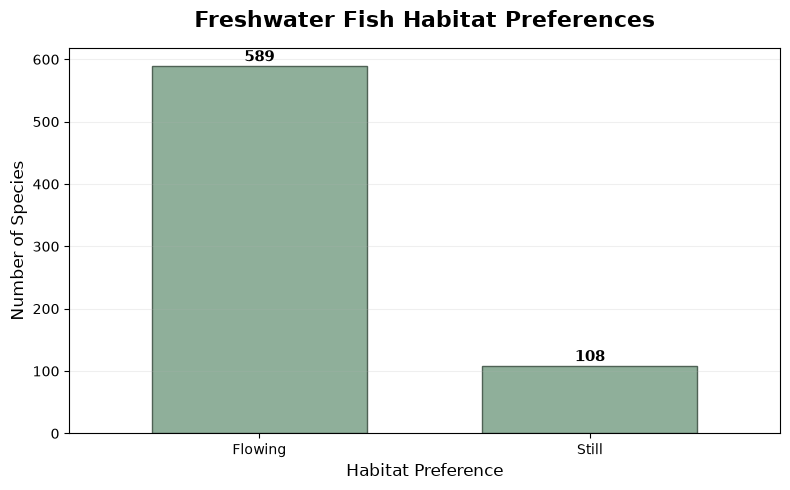

In [19]:
counts = model_data["HABITAT_TARGET"].value_counts()

ax = counts.plot(
    kind="bar",
    figsize=(8, 5),
    color="#8FAF9A",
    edgecolor="#4F6255",
    width=0.65
)

plt.title(
    "Freshwater Fish Habitat Preferences",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Habitat Preference", fontsize=12)
plt.ylabel("Number of Species", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)

# Add count above each bar
for i, value in enumerate(counts):
    ax.text(
        i,
        value + 8,
        str(value),
        ha="center",
        fontweight="bold",
        fontsize=11
    )

plt.tight_layout()
plt.show()

### Habitat Preference Distribution

The dataset shows a clear class imbalance between the two habitat preference groups. Of the 697 species with a defined target, 589 are classified as preferring flowing water habitats, while 108 are classified as preferring still water habitats.

Because the flowing water class is much larger, accuracy alone may not provide a complete picture of model performance. Metrics such as precision, recall, F1 score, and balanced accuracy will also be considered when evaluating the models.

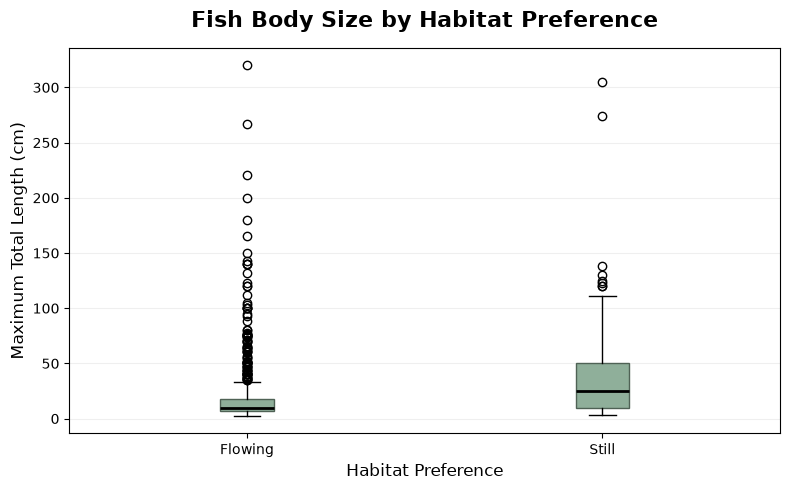

In [20]:
flowing_size = model_data.loc[
    model_data["HABITAT_TARGET"] == "Flowing", "MAXTL"
].dropna()

still_size = model_data.loc[
    model_data["HABITAT_TARGET"] == "Still", "MAXTL"
].dropna()

plt.figure(figsize=(8, 5))

plt.boxplot(
    [flowing_size, still_size],
    tick_labels=["Flowing", "Still"],
    patch_artist=True,
    boxprops=dict(facecolor="#8FAF9A", edgecolor="#4F6255"),
    medianprops=dict(color="black", linewidth=2)
)

plt.title(
    "Fish Body Size by Habitat Preference",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Habitat Preference", fontsize=12)
plt.ylabel("Maximum Total Length (cm)", fontsize=12)
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

### Body Size and Habitat Preference

The distribution of maximum body length differs between the two habitat groups. Fish classified with a still water preference generally have a higher median maximum length and a wider range of typical body sizes than fish classified with a flowing water preference.

Both groups also contain several large outliers, showing that unusually large species occur in both habitat categories. This suggests that body size may provide useful information for predicting habitat preference, although it is unlikely to determine habitat preference by itself.

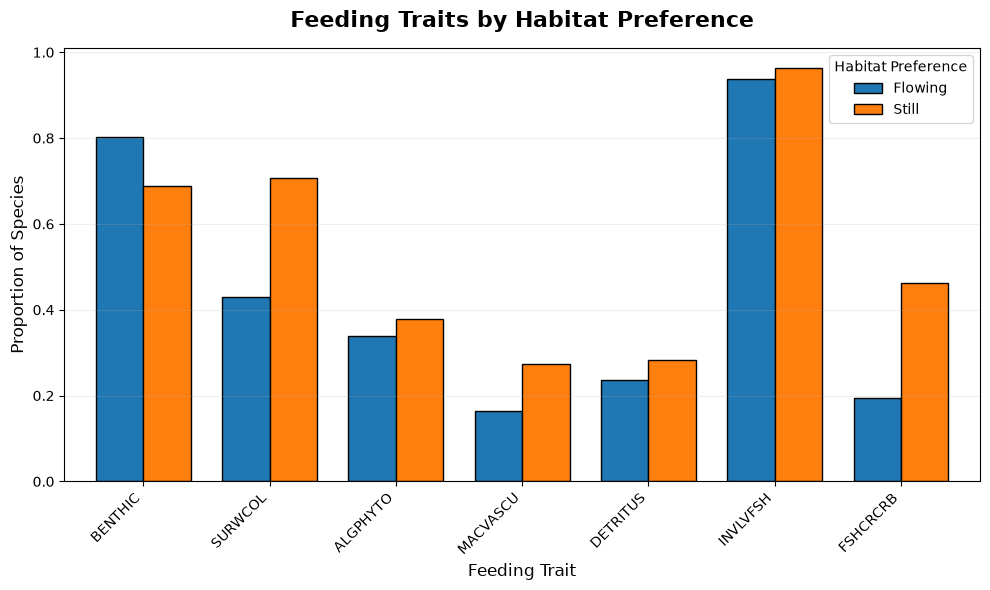

In [21]:
feeding_features = [
    "BENTHIC",
    "SURWCOL",
    "ALGPHYTO",
    "MACVASCU",
    "DETRITUS",
    "INVLVFSH",
    "FSHCRCRB"
]

feeding_by_habitat = model_data.groupby(
    "HABITAT_TARGET"
)[feeding_features].mean().T

feeding_by_habitat.plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black",
    width=0.75
)

plt.title(
    "Feeding Traits by Habitat Preference",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Feeding Trait", fontsize=12)
plt.ylabel("Proportion of Species", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.legend(title="Habitat Preference")

plt.tight_layout()
plt.show()

### Feeding Ecology and Habitat Preference

Several feeding traits differ between the two habitat preference groups. Still water species show higher proportions of surface or water column feeding and feeding on larger fish or crayfish, while flowing water species show a higher proportion of benthic feeding.

Feeding on invertebrates is common in both groups, suggesting that some feeding traits may be more useful than others for distinguishing habitat preference. These patterns support including feeding ecology variables as potential predictors in the machine learning models.

In [22]:
features = [
    "MAXTL",
    "MATUAGE",
    "LONGEVITY",
    "FECUNDITY",
    "BENTHIC",
    "SURWCOL",
    "ALGPHYTO",
    "MACVASCU",
    "DETRITUS",
    "INVLVFSH",
    "FSHCRCRB",
    "MINTEMP",
    "MAXTEMP"
]

X = model_data[features]
y = model_data["HABITAT_TARGET"]

X.shape, y.shape

((697, 13), (697,))

### Train/Test Split

The data is divided into 80% training data and 20% testing data. A stratified split is used to maintain approximately the same proportion of flowing water and still water species in both sets. A fixed random state is used so that the split can be reproduced.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (557, 13)
Testing set: (140, 13)


### Baseline Model

Before training the machine learning models, a baseline classifier is used for comparison. The baseline always predicts the most common habitat class. The Decision Tree and Random Forest models should provide better predictive performance than this simple strategy.

In [24]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

print("Baseline Accuracy:",
      accuracy_score(y_test, baseline_predictions))

print("Baseline Balanced Accuracy:",
      balanced_accuracy_score(y_test, baseline_predictions))

Baseline Accuracy: 0.8428571428571429
Baseline Balanced Accuracy: 0.5


### Baseline Results

The baseline model achieved an accuracy of approximately 84.3%, but its balanced accuracy was only 50%. The high accuracy is caused by the class imbalance because the baseline predicts the majority flowing water class for every species.

The balanced accuracy shows that the baseline does not effectively distinguish between flowing water and still water species. Therefore, the machine learning models should be evaluated using balanced accuracy and additional classification metrics rather than accuracy alone.

### Model 1: Decision Tree Classifier

The first machine learning model is a Decision Tree Classifier. Decision trees can capture nonlinear relationships between fish characteristics and habitat preference while also providing an interpretable model.

Missing predictor values are handled using median imputation within a machine learning pipeline. This allows preprocessing to be learned from the training data without using information from the test set.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

decision_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

decision_tree.fit(X_train, y_train)

tree_predictions = decision_tree.predict(X_test)

In [26]:
from sklearn.metrics import classification_report

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, tree_predictions)
)

print(
    "Decision Tree Balanced Accuracy:",
    balanced_accuracy_score(y_test, tree_predictions)
)

print("\nClassification Report:")
print(classification_report(y_test, tree_predictions))

Decision Tree Accuracy: 0.8
Decision Tree Balanced Accuracy: 0.6224961479198767

Classification Report:
              precision    recall  f1-score   support

     Flowing       0.88      0.88      0.88       118
       Still       0.36      0.36      0.36        22

    accuracy                           0.80       140
   macro avg       0.62      0.62      0.62       140
weighted avg       0.80      0.80      0.80       140



### Decision Tree Results

The Decision Tree achieved an overall accuracy of 80.0% and a balanced accuracy of approximately 62.2%. Although its overall accuracy was lower than the baseline model's 84.3%, its balanced accuracy improved from 50.0% to 62.2%.

The model performed much better on flowing water species, with an F1 score of 0.88, compared with an F1 score of 0.36 for still water species. This indicates that the Decision Tree is beginning to distinguish between the two habitat groups, but it still has difficulty correctly identifying species in the smaller still water class.

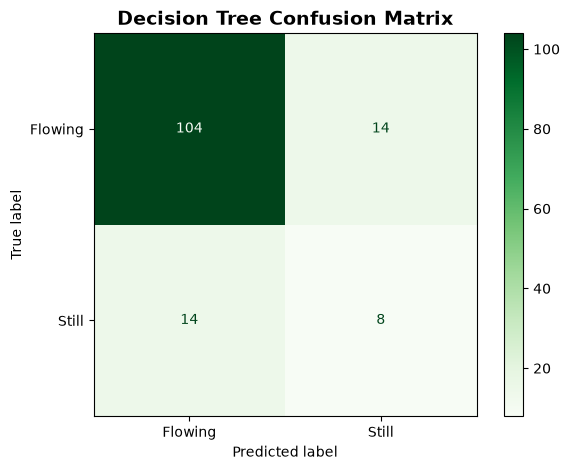

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_predictions,
    cmap="Greens"
)

plt.title(
    "Decision Tree Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.grid(False)
plt.tight_layout()
plt.show()

### Decision Tree Confusion Matrix

The confusion matrix shows that the Decision Tree correctly classified 104 of the 118 flowing water species and 8 of the 22 still water species in the test set. It misclassified 14 flowing water species as still water and 14 still water species as flowing water.

The model performs substantially better on the majority flowing water class. Its difficulty identifying still water species reflects the class imbalance and shows why accuracy alone is not sufficient for evaluating this problem.

In [28]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

random_forest.fit(X_train, y_train)

forest_predictions = random_forest.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, forest_predictions)
)

print(
    "Random Forest Balanced Accuracy:",
    balanced_accuracy_score(y_test, forest_predictions)
)

print("\nClassification Report:")
print(classification_report(y_test, forest_predictions))

Random Forest Accuracy: 0.8357142857142857
Random Forest Balanced Accuracy: 0.6806625577812019

Classification Report:
              precision    recall  f1-score   support

     Flowing       0.90      0.91      0.90       118
       Still       0.48      0.45      0.47        22

    accuracy                           0.84       140
   macro avg       0.69      0.68      0.68       140
weighted avg       0.83      0.84      0.83       140



### Random Forest Results

The Random Forest achieved an overall accuracy of approximately 83.6% and a balanced accuracy of approximately 68.1%. Its overall accuracy was similar to the baseline, but its balanced accuracy was substantially higher.

The model performed very well on flowing water species, with an F1 score of 0.90. Performance on still water species remained lower, but improved to an F1 score of 0.47 and a recall of 0.45. Compared with the Decision Tree, the Random Forest showed better overall balance between the two habitat classes.

These results suggest that combining multiple decision trees improves the model's ability to identify habitat preference, although predicting the smaller still water class remains challenging.

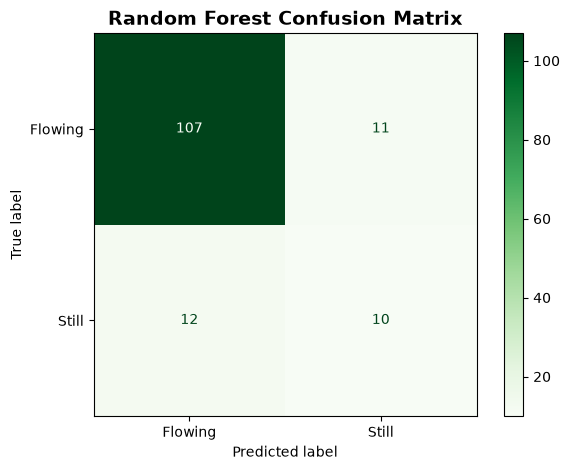

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_predictions,
    cmap="Greens"
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.grid(False)
plt.tight_layout()
plt.show()

### Random Forest Confusion Matrix

The Random Forest correctly classified 107 of the 118 flowing water species and 10 of the 22 still water species in the test set. It misclassified 11 flowing water species as still water and 12 still water species as flowing water.

Compared with the Decision Tree, the Random Forest correctly identified more species in both habitat groups and made fewer total classification errors. However, the model still has more difficulty identifying still water species, which is likely influenced by the smaller number of still water examples in the dataset.

### Cross-Validation

To evaluate whether the Random Forest's performance is consistent across different subsets of the data, I used 5 fold stratified cross validation. Stratification helps maintain approximately the same proportion of flowing water and still water species in each fold.

Balanced accuracy is used as the primary cross validation metric because the target classes are imbalanced.

In [33]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    random_forest,
    X,
    y,
    cv=cv,
    scoring="balanced_accuracy"
)

print("Balanced Accuracy by Fold:")
print(cv_scores)

print("\nMean Balanced Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Balanced Accuracy by Fold:
[0.75154083 0.69915254 0.65753691 0.66505246 0.71953188]

Mean Balanced Accuracy: 0.6985629248341113
Standard Deviation: 0.03479307012250366


### Cross-Validation Results

Across the five folds, the Random Forest achieved balanced accuracy scores ranging from approximately 65.7% to 75.2%. The mean balanced accuracy was approximately 69.9%, with a standard deviation of about 3.5 percentage points.

The average cross validation performance is close to the 68.1% balanced accuracy obtained from the original test set. This suggests that the Random Forest's performance is reasonably consistent across different subsets of the data and is not dependent on a single train/test split.

### ROC-AUC Evaluation

ROC-AUC is used as an additional evaluation metric to measure how well the Random Forest distinguishes between flowing water and still water species across different classification thresholds.

In [34]:
from sklearn.metrics import roc_auc_score

forest_probabilities = random_forest.predict_proba(X_test)

still_index = list(
    random_forest.named_steps["model"].classes_
).index("Still")

still_probabilities = forest_probabilities[:, still_index]

roc_auc = roc_auc_score(
    (y_test == "Still").astype(int),
    still_probabilities
)

print("Random Forest ROC-AUC:", roc_auc)

Random Forest ROC-AUC: 0.8572804314329738


### ROC-AUC Results

The Random Forest achieved a ROC-AUC score of approximately 0.857. This indicates that the model has a strong ability to distinguish between flowing water and still water species based on the selected biological and environmental characteristics.

The ROC-AUC result provides additional evidence that the model is learning meaningful differences between the two habitat groups, even though classification of the smaller still water class remains more difficult at the default classification threshold.

### Random Forest Hyperparameter Tuning

To improve the Random Forest, I used grid search with 5 fold stratified cross validation to compare multiple combinations of model settings. Balanced accuracy was used to select the best model because the habitat classes are imbalanced.

The tuning process evaluates different numbers of trees, tree depths, minimum sample requirements, and feature selection settings.

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Balanced Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Best Cross-Validation Balanced Accuracy:
0.7455495539014412


### Hyperparameter Tuning Results

Hyperparameter tuning improved the Random Forest's cross-validation performance. The best configuration used 300 trees, a maximum tree depth of 10, a minimum of 2 samples per leaf, a minimum of 5 samples required to split a node, and the square root of the available features considered at each split.

The tuned model achieved a cross validation balanced accuracy of approximately 74.6%, compared with approximately 69.9% for the original Random Forest. This suggests that controlling the complexity of the individual trees improved the model's ability to generalize across different subsets of the training data.

In [36]:
tuned_forest = grid_search.best_estimator_

tuned_predictions = tuned_forest.predict(X_test)

print(
    "Tuned Random Forest Accuracy:",
    accuracy_score(y_test, tuned_predictions)
)

print(
    "Tuned Random Forest Balanced Accuracy:",
    balanced_accuracy_score(y_test, tuned_predictions)
)

print("\nClassification Report:")
print(classification_report(y_test, tuned_predictions))

Tuned Random Forest Accuracy: 0.8071428571428572
Tuned Random Forest Balanced Accuracy: 0.7191833590138674

Classification Report:
              precision    recall  f1-score   support

     Flowing       0.92      0.85      0.88       118
       Still       0.42      0.59      0.49        22

    accuracy                           0.81       140
   macro avg       0.67      0.72      0.69       140
weighted avg       0.84      0.81      0.82       140



### Tuned Random Forest Evaluation

The tuned Random Forest achieved an overall accuracy of approximately 80.7% and a balanced accuracy of approximately 71.9%. Although its overall accuracy was slightly lower than the original Random Forest, its balanced accuracy improved from 68.1% to 71.9%.

The largest improvement occurred for the smaller still water class. Recall for still water species increased from 45% with the original Random Forest to 59% with the tuned model. This means the tuned model successfully identified a larger proportion of still water species rather than primarily favoring the majority flowing-water class.

Based on balanced accuracy and minority class recall, the tuned Random Forest was selected as the final model. For this imbalanced classification problem, these metrics provide a more informative evaluation than overall accuracy alone.

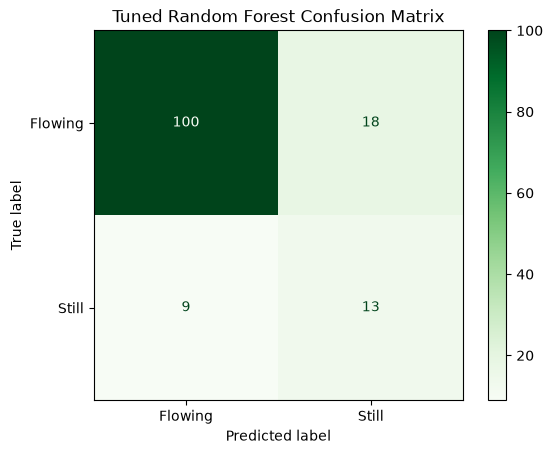

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_predictions,
    cmap="Greens"
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

In [37]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    tuned_forest,
    X_test,
    y_test,
    scoring="balanced_accuracy",
    n_repeats=20,
    random_state=42
)

feature_names = {
    "MAXTL": "Maximum Total Length",
    "MATUAGE": "Age at Maturity",
    "LONGEVITY": "Longevity",
    "FECUNDITY": "Fecundity",
    "BENTHIC": "Benthic Feeding",
    "SURWCOL": "Surface/Water Column Feeding",
    "ALGPHYTO": "Algae/Phytoplankton Feeding",
    "MACVASCU": "Aquatic Plant Feeding",
    "DETRITUS": "Detritus Feeding",
    "INVLVFSH": "Invertebrate Feeding",
    "FSHCRCRB": "Fish/Crayfish Feeding",
    "MINTEMP": "Minimum Temperature",
    "MAXTEMP": "Maximum Temperature"
}

permutation_df = pd.DataFrame({
    "Feature": [feature_names[f] for f in features],
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

permutation_df

,Feature,Importance
12,Maximum Temperature,0.078120
3,Fecundity,0.038752
5,Surface/Water Column Feeding,0.028062
11,Minimum Temperature,0.015023
10,Fish/Crayfish Feeding,0.014330
8,Detritus Feeding,0.006471
9,Invertebrate Feeding,-0.000212
4,Benthic Feeding,-0.000963
6,Algae/Phytoplankton Feeding,-0.001907
2,Longevity,-0.004257


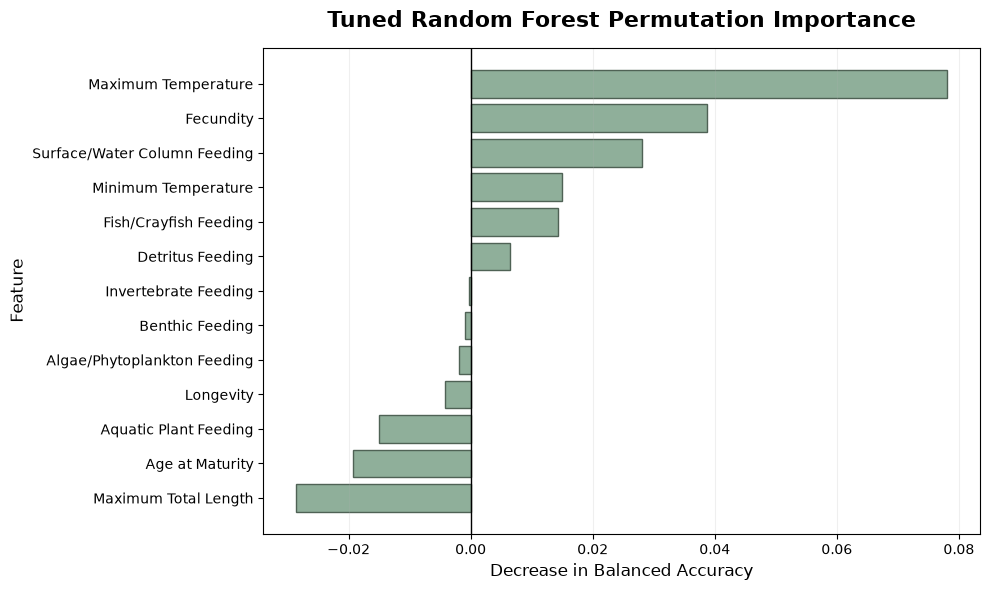

In [38]:
plt.figure(figsize=(10, 6))

plt.barh(
    permutation_df["Feature"],
    permutation_df["Importance"],
    color="#8FAF9A",
    edgecolor="#4F6255"
)

plt.gca().invert_yaxis()

plt.axvline(0, color="black", linewidth=1)

plt.title(
    "Tuned Random Forest Permutation Importance",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Decrease in Balanced Accuracy", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### Feature Importance

Permutation importance was used to examine which features contributed most to the tuned Random Forest's performance on the test data. Maximum temperature had the largest importance, followed by fecundity and surface/water column feeding. Minimum temperature and fish/crayfish feeding also contributed to the model's predictions.

Several features had importance values close to or below zero. This does not mean that these traits have a negative biological effect on habitat preference. Instead, it means that shuffling those variables did not reduce the model's balanced accuracy in this test set. Some of these variables may provide information that overlaps with other features.

Overall, the results suggest that environmental conditions, reproductive characteristics, and feeding behavior were useful for distinguishing between flowing water and still water species. However, these results describe how the model makes predictions and should not be interpreted as evidence that these traits directly cause habitat preference.

In [39]:
error_analysis = model_data.loc[
    X_test.index,
    ["COMMONNAME", "HABITAT_TARGET"]
].copy()

error_analysis["Predicted"] = tuned_predictions

errors = error_analysis[
    error_analysis["HABITAT_TARGET"] != error_analysis["Predicted"]
]

print("Total Misclassified Species:", len(errors))

errors.head(10)

Total Misclassified Species: 27


,COMMONNAME,HABITAT_TARGET,Predicted
4,Atlantic sturgeon,Flowing,Still
362,Chihuahua chub,Flowing,Still
493,striped bass,Flowing,Still
520,bluehead chub,Flowing,Still
462,blacktip shiner,Flowing,Still
785,Bear Lake whitefish,Still,Flowing
735,sauger,Flowing,Still
701,Clear Lake splittail,Still,Flowing
789,mountain whitefish,Flowing,Still
775,shortnose cisco,Still,Flowing


### Error Analysis

The tuned Random Forest misclassified 27 of the 140 species in the test set. Examples of flowing water species that were incorrectly predicted as still water species include the Atlantic sturgeon, Chihuahua chub, striped bass, and mountain whitefish. Still water species such as the Bear Lake whitefish, Clear Lake splittail, and shortnose cisco were incorrectly predicted as flowing water species.

Although the tuned model made more total errors than the original Random Forest, it became better at identifying the smaller still water class. Recall for still water species increased from 45% to 59%. This tradeoff was considered worthwhile because the dataset contains far fewer still water species, making overall accuracy alone less informative.

The remaining errors also show that fish with different habitat preferences can share similar biological and environmental characteristics. The selected features provide useful predictive information, but they cannot perfectly separate the two habitat groups.

## 4. Limitations and Ethics

This project has several limitations. First, the dataset is imbalanced, with substantially more flowing water species than still water species. This makes the smaller still water class more difficult for the models to predict accurately.

The target variable also simplifies habitat preference into only two categories: flowing water and still water. Fish habitat use can be more complex, and some species may use multiple habitat types. Species without a clear preference were excluded from the modeling dataset.

Several predictor variables contained missing values that had to be imputed before modeling. Although imputation allows more species to remain in the analysis, the estimated values may not perfectly represent the missing biological characteristics. The preprocessing was performed within the machine learning pipelines so that information from the test set was not used to calculate the imputed values.

Finally, the relationships identified by the models should not be interpreted as causal. Feature importance indicates which variables were useful for prediction, but it does not prove that those characteristics cause a fish species to prefer a particular habitat. The model should therefore be treated as an exploratory prediction tool rather than a replacement for ecological research or expert assessment.

Because incorrect predictions could misrepresent a species' habitat needs, this model should not be used by itself to make conservation, stocking, or habitat management decisions.

## 5. Conclusion

This project examined whether machine learning could predict whether a freshwater fish species prefers flowing-water or still water habitats using biological and environmental characteristics. The results show that these characteristics can provide useful information for predicting habitat preference, although the two habitat groups were not equally easy to identify.

The baseline model achieved 84.3% accuracy but only 50.0% balanced accuracy because it predicted the majority flowing water class. The Decision Tree improved balanced accuracy to 62.2%, and the original Random Forest increased it to 68.1%. After hyperparameter tuning, the final Random Forest achieved 80.7% accuracy and 71.9% balanced accuracy.

Although tuning slightly reduced overall accuracy, it improved recall for still water species from 45% to 59%. Because still water species make up a much smaller portion of the dataset, I considered this improvement more important than maximizing overall accuracy. For this reason, the tuned Random Forest was selected as the final model.

Permutation importance showed that maximum temperature, fecundity, and surface/water-column feeding were among the most useful features for the final model. However, these results should not be interpreted as evidence that these traits cause a species to prefer a particular habitat.

Overall, the project demonstrates that machine learning can identify patterns related to freshwater fish habitat preference, but the model still has limitations. Future work could include additional habitat variables, more examples of still water species, and other modeling approaches to improve predictions for the minority class.

## References
Frimpong, E. A., & Angermeier, P. L. (2009). Fish traits: A database of ecological and life-history traits of freshwater fishes of the United States. *Fisheries, 34*(10), 487–495. https://doi.org/10.1577/1548-8446-34.10.487

Goldstein, R. M., & Meador, M. R. (2004). Comparisons of fish species traits from small streams to large rivers. *Transactions of the American Fisheries Society, 133*(4), 971–983. https://doi.org/10.1577/T03-080.1

Goldstein, R. M., & Meador, M. R. (2005). Multilevel assessment of fish species traits to evaluate habitat degradation in streams of the Upper Midwest. *North American Journal of Fisheries Management, 25*(1), 180–194. https://doi.org/10.1577/M04-042.1

## Code and AI Transparency

### Code
The complete Python analysis for this project is available in my GitHub repository:

[GitHub Repository](https://github.com/LockdownKam/Data-Structures-Portfolio/blob/main/Aquarium_Research_Project.ipynb)

### AI Usage Disclosure
I used ChatGPT (OpenAI, GPT-5.6) as a support tool while completing this project. I used it to help troubleshoot Python errors, understand machine learning concepts and evaluation metrics, improve the fluency and organization of my code, and improve the clarity of some written explanations. I wrote, ran, and reviewed the code used in the analysis and examined the model results to make the final decisions presented in the project.